# Sistema de lógica difusa - Numeral 2.2

Este notebook implementa un sistema de lógica difusa con **Scikit-Fuzzy** para evaluar la **robustez requerida** de un sistema de seguridad según:

- Recursos.
- Sensibilidad de la información.
- Robustez requerida.

Cada celda incluye comentarios indicando qué requisito del numeral **2.2 Sistema de lógica difusa** se cumple.


In [1]:
# ============================================================
# IMPORTACIÓN DE LIBRERÍAS
# Requisito asociado:
#   - Implementar el sistema de lógica difusa usando Scikit-Fuzzy.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Configuración opcional para que las gráficas se vean dentro del notebook.
%matplotlib inline


In [2]:
# ============================================================
# 1. DEFINICIÓN DE UNIVERSOS DEL DISCURSO
# Requisito asociado:
#   - Para cada variable definir su universo del discurso.
#
# Descripción:
#   - recursos: porcentaje entre 0 y 100.
#   - sensibilidad: escala de 0 a 10.
#   - robustez: porcentaje entre 0 y 100.
# ============================================================

universo_recursos = np.arange(0, 101, 1)
universo_sensibilidad = np.arange(0, 11, 1)
universo_robustez = np.arange(0, 101, 1)

print("Universo de recursos:", universo_recursos[0], "a", universo_recursos[-1])
print("Universo de sensibilidad:", universo_sensibilidad[0], "a", universo_sensibilidad[-1])
print("Universo de robustez:", universo_robustez[0], "a", universo_robustez[-1])


Universo de recursos: 0 a 100
Universo de sensibilidad: 0 a 10
Universo de robustez: 0 a 100


In [3]:
# ============================================================
# 2. DEFINICIÓN DE VARIABLES DIFUSAS
# Requisito asociado:
#   - Definir al menos 3 variables difusas del dominio.
#
# Variables:
#   - recursos: variable de entrada o antecedente.
#   - sensibilidad: variable de entrada o antecedente.
#   - robustez: variable de salida o consecuente.
# ============================================================

recursos = ctrl.Antecedent(universo_recursos, 'recursos')
sensibilidad = ctrl.Antecedent(universo_sensibilidad, 'sensibilidad')
robustez = ctrl.Consequent(universo_robustez, 'robustez')


In [4]:
# ============================================================
# 3. DEFINICIÓN DEL MÉTODO DE DEFUZZIFICACIÓN
# Requisito asociado:
#   - Implementar un proceso de defuzzificación justificado.
#
# Justificación:
#   - Se usa el método del centroide porque calcula el centro de gravedad
#     del área difusa agregada de salida.
#   - Esto permite obtener un valor numérico continuo y representativo
#     del nivel de robustez requerido.
#   - Es adecuado porque la salida "robustez" se interpreta como un
#     porcentaje entre 0 % y 100 %.
# ============================================================

robustez.defuzzify_method = 'centroid'


In [5]:
# ============================================================
# 4. FUNCIONES DE PERTENENCIA PARA LA VARIABLE "RECURSOS"
# Requisitos asociados:
#   - Para cada variable tener mínimo 3 valores difusos.
#   - Asociar cada valor difuso con una función de pertenencia.
#   - Incluir funciones trapezoidales, triangulares y gaussianas
#     en el sistema completo.
#
# Valores difusos de recursos:
#   - Bajo: función trapezoidal.
#   - Medio: función triangular.
#   - Alto: función gaussiana.
# ============================================================

recursos_bajo = fuzz.trapmf(recursos.universe, [0, 0, 25, 50])
recursos_medio = fuzz.trimf(recursos.universe, [25, 50, 75])
recursos_alto = fuzz.gaussmf(recursos.universe, 100, 25)


In [6]:
# ============================================================
# 5. FUNCIONES DE PERTENENCIA PARA LA VARIABLE "SENSIBILIDAD"
# Requisitos asociados:
#   - Para cada variable tener mínimo 3 valores difusos.
#   - Asociar cada valor difuso con una función de pertenencia.
#
# Valores difusos de sensibilidad:
#   - Publica: función trapezoidal.
#   - Confidencial: función triangular.
#   - Secreta: función gaussiana.
# ============================================================

sensibilidad_publica = fuzz.trapmf(sensibilidad.universe, [0, 0, 2, 4])
sensibilidad_confidencial = fuzz.trimf(sensibilidad.universe, [2, 4, 6])
sensibilidad_secreta = fuzz.gaussmf(sensibilidad.universe, 8, 2.5)


In [7]:
# ============================================================
# 6. FUNCIONES DE PERTENENCIA PARA LA VARIABLE "ROBUSTEZ"
# Requisitos asociados:
#   - Para cada variable tener mínimo 3 valores difusos.
#   - Asociar cada valor difuso con una función de pertenencia.
#
# Valores difusos de robustez:
#   - Baja: función trapezoidal.
#   - Media: función triangular.
#   - Militar: función gaussiana.
# ============================================================

robustez_baja = fuzz.trapmf(robustez.universe, [0, 0, 10, 25])
robustez_media = fuzz.trimf(robustez.universe, [20, 50, 80])
robustez_militar = fuzz.gaussmf(robustez.universe, 100, 15)


In [8]:
# ============================================================
# 7. MODIFICADORES LINGÜÍSTICOS
# Requisito asociado:
#   - Hacer uso de dos casos de modificadores, por ejemplo:
#     "muy", "ligeramente", etc.
#
# Modificador 1:
#   - "Muy secreta" se obtiene elevando al cuadrado la pertenencia
#     del conjunto "Secreta".
#   - Fórmula usada:
#       μ_muy_A(x) = [μ_A(x)]^2
#
# Modificador 2:
#   - "Ligeramente bajo" se obtiene aplicando raíz cuadrada a la
#     pertenencia del conjunto "Bajo".
#   - Fórmula usada:
#       μ_ligeramente_A(x) = sqrt(μ_A(x))
# ============================================================

sensibilidad_muy_secreta = np.power(sensibilidad_secreta, 2)
recursos_ligeramente_bajo = np.sqrt(recursos_bajo)


In [9]:
# ============================================================
# 8. REGISTRO DE ETIQUETAS DIFUSAS EN EL SISTEMA
# Requisitos asociados:
#   - Cada variable debe tener sus valores difusos registrados.
#   - Cada valor difuso debe estar asociado a su función de pertenencia.
#
# Nota:
#   - Además de los 3 valores mínimos por variable, se agregan dos
#     valores modificados: "Ligeramente_bajo" y "Muy_secreta".
# ============================================================

recursos['Bajo'] = recursos_bajo
recursos['Medio'] = recursos_medio
recursos['Alto'] = recursos_alto
recursos['Ligeramente_bajo'] = recursos_ligeramente_bajo

sensibilidad['Publica'] = sensibilidad_publica
sensibilidad['Confidencial'] = sensibilidad_confidencial
sensibilidad['Secreta'] = sensibilidad_secreta
sensibilidad['Muy_secreta'] = sensibilidad_muy_secreta

robustez['Baja'] = robustez_baja
robustez['Media'] = robustez_media
robustez['Militar'] = robustez_militar


## Visualización de las funciones de pertenencia

Estas gráficas sirven para evidenciar que cada variable tiene sus valores difusos asociados a funciones de pertenencia.


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/skfuzzy/control/fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


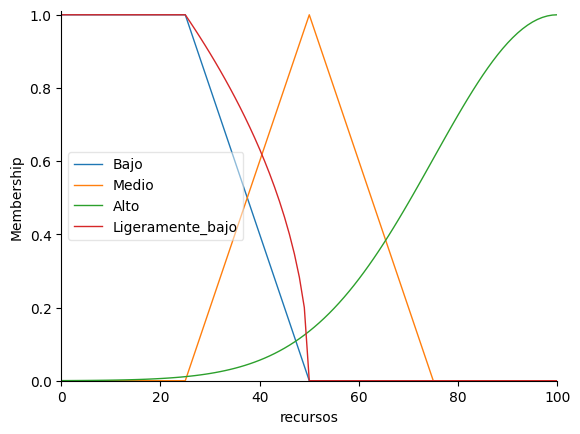

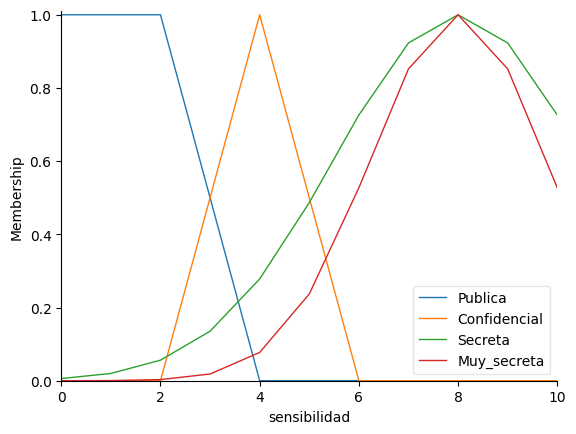

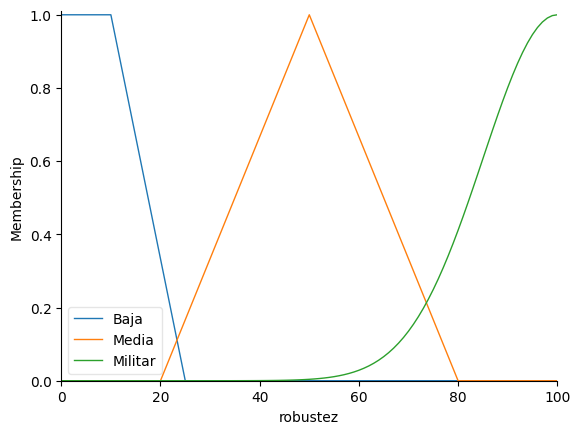

In [10]:
# ============================================================
# 9. VISUALIZACIÓN DE LOS CONJUNTOS DIFUSOS DE ENTRADA Y SALIDA
# Requisito asociado:
#   - Evidenciar las funciones de pertenencia de cada variable.
#
# Aquí se muestran:
#   - Recursos: Bajo, Medio, Alto, Ligeramente_bajo.
#   - Sensibilidad: Publica, Confidencial, Secreta, Muy_secreta.
#   - Robustez: Baja, Media, Militar.
# ============================================================

recursos.view()
plt.show()

sensibilidad.view()
plt.show()

robustez.view()
plt.show()


In [11]:
# ============================================================
# 10. DEFINICIÓN DE REGLAS DIFUSAS
# Requisitos asociados:
#   - Definir al menos 9 reglas difusas.
#   - Incluir operadores:
#       * Intersección / AND: &
#       * Unión / OR: |
#       * Complemento / Negación: ~
#
# Reglas:
#   - Las reglas relacionan recursos y sensibilidad con el nivel
#     de robustez requerido.
# ============================================================

# Regla 1 - Usa AND (&)
# Si los recursos son altos y la sensibilidad es pública,
# entonces la robustez requerida es baja.
regla_1 = ctrl.Rule(
    recursos['Alto'] & sensibilidad['Publica'],
    robustez['Baja']
)

# Regla 2 - Usa AND (&)
# Si los recursos son medios y la sensibilidad es pública,
# entonces la robustez requerida es media.
regla_2 = ctrl.Rule(
    recursos['Medio'] & sensibilidad['Publica'],
    robustez['Media']
)

# Regla 3 - Usa AND (&)
# Si los recursos son bajos y la sensibilidad es pública,
# entonces la robustez requerida es media.
regla_3 = ctrl.Rule(
    recursos['Bajo'] & sensibilidad['Publica'],
    robustez['Media']
)

# Regla 4 - Usa AND (&)
# Si los recursos son medios y la sensibilidad es confidencial,
# entonces la robustez requerida es media.
regla_4 = ctrl.Rule(
    recursos['Medio'] & sensibilidad['Confidencial'],
    robustez['Media']
)

# Regla 5 - Usa AND (&)
# Si los recursos son bajos y la sensibilidad es confidencial,
# entonces la robustez requerida es militar.
regla_5 = ctrl.Rule(
    recursos['Bajo'] & sensibilidad['Confidencial'],
    robustez['Militar']
)

# Regla 6 - Usa AND (&) y complemento / negación (~)
# Si la sensibilidad es secreta y los recursos NO son altos,
# entonces la robustez requerida es militar.
regla_6 = ctrl.Rule(
    sensibilidad['Secreta'] & ~recursos['Alto'],
    robustez['Militar']
)

# Regla 7 - Usa AND (&)
# Si los recursos son altos y la sensibilidad es secreta,
# entonces la robustez requerida es media.
regla_7 = ctrl.Rule(
    recursos['Alto'] & sensibilidad['Secreta'],
    robustez['Media']
)

# Regla 8 - Usa modificador lingüístico "Muy"
# Si la sensibilidad es muy secreta,
# entonces la robustez requerida es militar.
regla_8 = ctrl.Rule(
    sensibilidad['Muy_secreta'],
    robustez['Militar']
)

# Regla 9 - Usa OR (|) y dos modificadores lingüísticos
# Si los recursos son ligeramente bajos O la sensibilidad es muy secreta,
# entonces la robustez requerida es militar.
regla_9 = ctrl.Rule(
    recursos['Ligeramente_bajo'] | sensibilidad['Muy_secreta'],
    robustez['Militar']
)


In [12]:
# ============================================================
# 11. CREACIÓN DEL SISTEMA DE CONTROL DIFUSO
# Requisito asociado:
#   - Implementar el sistema experto difuso funcional.
#
# Se integran las 9 reglas dentro de un ControlSystem de Scikit-Fuzzy.
# ============================================================

sistema_control = ctrl.ControlSystem([
    regla_1,
    regla_2,
    regla_3,
    regla_4,
    regla_5,
    regla_6,
    regla_7,
    regla_8,
    regla_9
])


In [13]:
# ============================================================
# 12. CREACIÓN DE LA SIMULACIÓN
# Requisito asociado:
#   - Ejecutar el proceso de inferencia difusa.
#
# ControlSystemSimulation permite ingresar valores concretos,
# evaluar las reglas y obtener una salida defuzzificada.
# ============================================================

simulacion = ctrl.ControlSystemSimulation(sistema_control)


In [14]:
# ============================================================
# 13. ENTRADAS DE PRUEBA
# Requisito asociado:
#   - Probar el sistema de inferencia difusa con valores concretos.
#
# Caso de ejemplo:
#   - recursos = 10
#   - sensibilidad = 9
#
# Interpretación:
#   - Recursos bajos.
#   - Sensibilidad alta o cercana a secreta/muy secreta.
# ============================================================

simulacion.input['recursos'] = 10
simulacion.input['sensibilidad'] = 9


In [15]:
# ============================================================
# 14. INFERENCIA DIFUSA
# Requisito asociado:
#   - Aplicar las reglas difusas y obtener el resultado del sistema.
# ============================================================

simulacion.compute()


In [16]:
# ============================================================
# 15. RESULTADO DEFUZZIFICADO
# Requisito asociado:
#   - Obtener una salida concreta mediante defuzzificación.
#
# La salida es un valor porcentual de robustez requerida.
# ============================================================

resultado_robustez = simulacion.output['robustez']

print(f"La robustez requerida es: {resultado_robustez:.2f}%")


La robustez requerida es: 87.93%


In [17]:
# ============================================================
# 16. CLASIFICACIÓN FINAL DEL RESULTADO
# Requisito complementario:
#   - Aunque el sistema ya entrega una salida numérica defuzzificada,
#     esta función permite interpretar el porcentaje en una categoría
#     lingüística comprensible.
# ============================================================

def clasificar_robustez(valor):
    '''
    Clasifica el valor defuzzificado de robustez en una categoría lingüística.

    Parámetros:
        valor (float): porcentaje de robustez entre 0 y 100.

    Retorna:
        str: nivel de robustez clasificado.
    '''

    if valor < 30:
        return "Baja"
    elif valor < 70:
        return "Media"
    else:
        return "Militar"


nivel_robustez = clasificar_robustez(resultado_robustez)

print("Nivel de robustez clasificado:", nivel_robustez)


Nivel de robustez clasificado: Militar


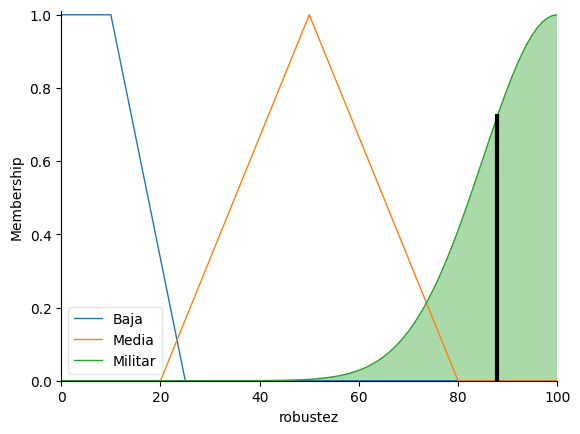

In [18]:
# ============================================================
# 17. VISUALIZACIÓN DE LA SALIDA DEFUZZIFICADA
# Requisito asociado:
#   - Evidenciar visualmente el resultado del proceso de inferencia
#     y defuzzificación.
#
# La gráfica muestra:
#   - Las funciones de pertenencia de la variable de salida.
#   - La zona activada por las reglas.
#   - El valor defuzzificado obtenido.
# ============================================================

robustez.view(sim=simulacion)
plt.show()


## Prueba opcional con otros valores

Puedes cambiar los valores de `valor_recursos` y `valor_sensibilidad` para probar otros escenarios sin reescribir todo el sistema.


Recursos: 10
Sensibilidad: 9
Robustez requerida: 87.93%
Clasificación: Militar


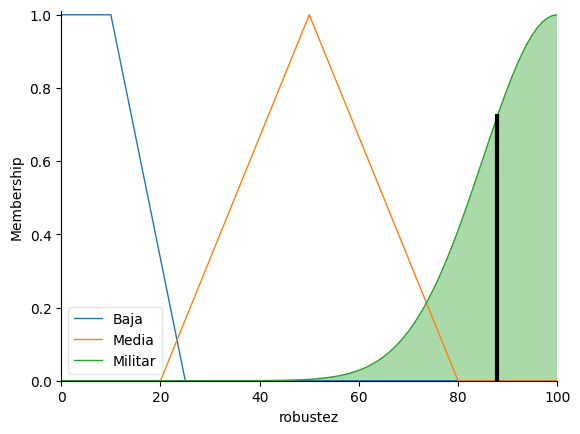

(np.float64(87.92549907960036), 'Militar')

In [19]:
# ============================================================
# 18. FUNCIÓN PARA PROBAR OTROS CASOS
# Requisito complementario:
#   - Facilita validar el comportamiento del sistema con diferentes entradas.
# ============================================================

def evaluar_robustez(valor_recursos, valor_sensibilidad):
    '''
    Evalúa el sistema difuso para un par de entradas dado.

    Parámetros:
        valor_recursos (float): valor entre 0 y 100.
        valor_sensibilidad (float): valor entre 0 y 10.

    Retorna:
        tuple: resultado defuzzificado y clasificación lingüística.
    '''

    nueva_simulacion = ctrl.ControlSystemSimulation(sistema_control)

    nueva_simulacion.input['recursos'] = valor_recursos
    nueva_simulacion.input['sensibilidad'] = valor_sensibilidad

    nueva_simulacion.compute()

    resultado = nueva_simulacion.output['robustez']
    clasificacion = clasificar_robustez(resultado)

    print(f"Recursos: {valor_recursos}")
    print(f"Sensibilidad: {valor_sensibilidad}")
    print(f"Robustez requerida: {resultado:.2f}%")
    print(f"Clasificación: {clasificacion}")

    robustez.view(sim=nueva_simulacion)
    plt.show()

    return resultado, clasificacion


# Ejemplo opcional:
evaluar_robustez(valor_recursos=10, valor_sensibilidad=9)


## Resumen de cumplimiento del numeral 2.2

1. **Al menos 3 variables difusas**
   - `recursos`
   - `sensibilidad`
   - `robustez`

2. **Mínimo 3 valores difusos por variable**
   - `recursos`: Bajo, Medio, Alto.
   - `sensibilidad`: Publica, Confidencial, Secreta.
   - `robustez`: Baja, Media, Militar.

3. **Universo del discurso por variable**
   - `recursos`: 0 a 100.
   - `sensibilidad`: 0 a 10.
   - `robustez`: 0 a 100.

4. **Funciones de pertenencia usadas**
   - Trapezoidal: `trapmf`.
   - Triangular: `trimf`.
   - Gaussiana: `gaussmf`.

5. **Modificadores**
   - `Muy_secreta = Secreta^2`.
   - `Ligeramente_bajo = sqrt(Bajo)`.

6. **Reglas difusas**
   - 9 reglas definidas.

7. **Operadores**
   - AND: `&`.
   - OR: `|`.
   - NOT: `~`.

8. **Defuzzificación**
   - Método del centroide.
   - Justificado por entregar una salida continua, balanceada y representativa del área difusa agregada.
